# Chapter 13 — Data Acquisition Fundamentals: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end. All exercises run in Google Colab with no
> additional hardware and use only NumPy, SciPy, and Matplotlib.

| Exercise | Topic | Key technique |
|----------|-------|---------------|
| 13.1 | Sampling and aliasing | Nyquist–Shannon theorem, frequency-folding, coherent vs. non-coherent sampling |
| 13.2 | Quantization and SQNR | Mid-rise uniform quantizer, resolution sweep, amplitude utilisation |
| 13.3 | Anti-aliasing filtering | Causal analog Butterworth filter, guard band, group delay |
| 13.4 | Clock jitter and ENOB | Aperture jitter, effective number of bits, repeated Monte Carlo trials |


---
## Setup

In [1]:
# -- Setup ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lsim, freqs, filtfilt

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.5,
})
print("Environment ready.")

Environment ready.


---
## Exercise 13.1 -- Sampling and the Nyquist-Shannon Theorem

### Background

The Nyquist-Shannon theorem states that a band-limited signal with maximum
frequency $f_{max}$ can be reconstructed exactly from its samples only if
the sampling rate exceeds the Nyquist *rate*, $f_s > 2f_{max}$ (the
quantity $2f_{max}$ is the Nyquist rate for that particular signal; the
quantity $f_s/2$ is the Nyquist *frequency* of the sampler itself -- the
two terms are related but not interchangeable). When the condition is
violated, the signal does not disappear from the digitised record -- it
reappears at a different, lower frequency, an effect known as
**aliasing**. This exercise samples a single 10 Hz sine wave at five
different rates and verifies, both analytically and by direct spectral
measurement, exactly which frequency an undersampled signal is mistaken
for.

A note on methodology: the record length (2 s) and test frequencies in
this exercise were deliberately chosen so that every frequency of
interest is an exact multiple of the FFT's bin resolution
($\Delta f = 1/T = 0.5$ Hz). This is called **coherent sampling**, and it
is why the table below matches the analytic prediction essentially
exactly. It is a controlled demonstration, not a claim that real-world
spectral measurements are always this clean -- the last part of this
exercise deliberately breaks coherence to show what changes.

In [2]:
# -- Exercise 13.1: Sampling and aliasing ------------------------------
f0 = 10.0            # Hz, signal of interest
duration = 2.0        # s (bin resolution df = 1/duration = 0.5 Hz)
fs_list = [8, 15, 22, 50, 200]   # Hz, sampling rates under test


def fold_frequency(f_true: float, fs: float) -> float:
    # Analytic aliasing folding formula: returns the apparent frequency
    # in [0, fs/2] that a tone at f_true will be mistaken for at fs.
    f_mod = f_true % fs
    if f_mod > fs / 2:
        f_mod = fs - f_mod
    return f_mod


def measured_alias_freq(fs: float):
    # Sample the signal at fs and find the FFT peak frequency.
    t_samples = np.arange(0, duration, 1 / fs)
    samples = np.sin(2 * np.pi * f0 * t_samples)
    n = len(samples)
    spectrum = np.abs(np.fft.rfft(samples * np.hanning(n)))
    freqs_ = np.fft.rfftfreq(n, d=1 / fs)
    spectrum[0] = 0.0                       # ignore DC bin
    return freqs_[np.argmax(spectrum)]


print(f"{'fs (Hz)':>8} {'Nyquist f_s/2':>13} {'fs / (2 f0)':>12} "
      f"{'predicted alias':>16} {'measured alias':>15} {'abs err (Hz)':>13}")
print("-" * 82)
results = []
for fs in fs_list:
    predicted = fold_frequency(f0, fs)
    measured = measured_alias_freq(fs)
    err = abs(predicted - measured)
    results.append((fs, fs / 2, fs / (2*f0), predicted, measured, err))
    print(f"{fs:8d} {fs/2:13.2f} {fs/(2*f0):12.2f} "
          f"{predicted:16.3f} {measured:15.3f} {err:13.3f}")

 fs (Hz) Nyquist f_s/2  fs / (2 f0)  predicted alias  measured alias  abs err (Hz)
----------------------------------------------------------------------------------
       8          4.00         0.40            2.000           2.000         0.000
      15          7.50         0.75            5.000           5.000         0.000
      22         11.00         1.10           10.000          10.000         0.000
      50         25.00         2.50           10.000          10.000         0.000
     200        100.00        10.00           10.000          10.000         0.000


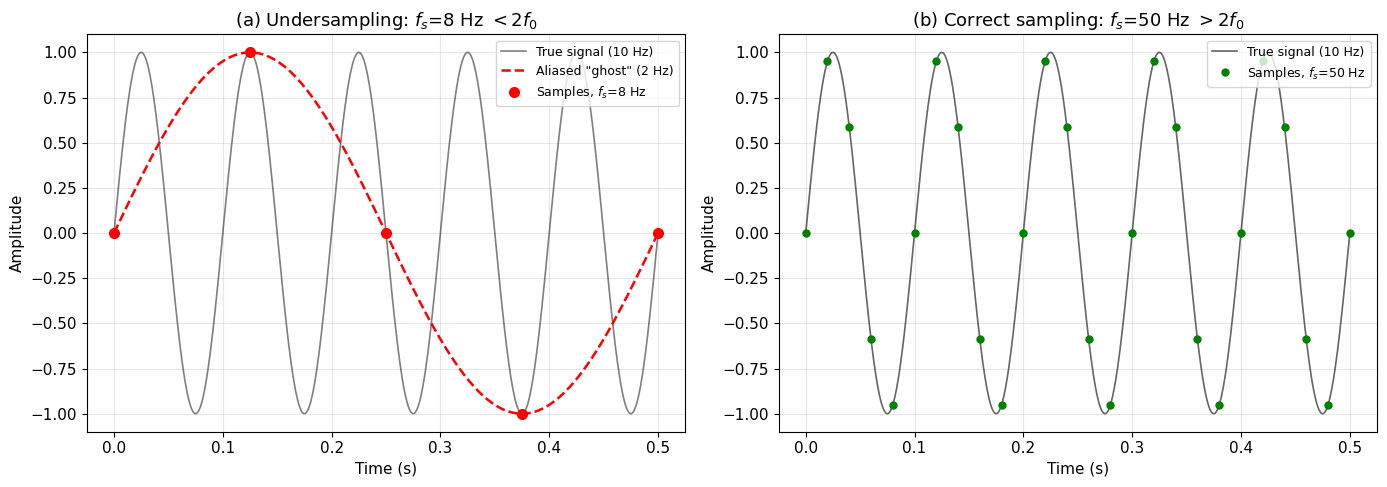

In [3]:
# -- Figure 13.1: aliasing in the time and frequency domain -----------
t_cont = np.linspace(0, duration, 4000)
sig_cont = np.sin(2 * np.pi * f0 * t_cont)

fs_bad, fs_good = 8, 50
t_bad = np.arange(0, duration, 1 / fs_bad)
s_bad = np.sin(2 * np.pi * f0 * t_bad)
t_good = np.arange(0, duration, 1 / fs_good)
s_good = np.sin(2 * np.pi * f0 * t_good)
f_alias = fold_frequency(f0, fs_bad)
ghost = np.sin(2 * np.pi * f_alias * t_cont)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
zoom = 0.5

ax = axes[0]
m = t_cont <= zoom
ax.plot(t_cont[m], sig_cont[m], 'k-', lw=1.2, alpha=0.5,
        label=f'True signal ({f0:.0f} Hz)')
ax.plot(t_cont[m], ghost[m], 'r--', lw=1.8,
        label=f'Aliased "ghost" ({f_alias:.0f} Hz)')
ax.plot(t_bad[t_bad <= zoom], s_bad[t_bad <= zoom], 'ro', ms=7,
        label=f'Samples, $f_s$={fs_bad} Hz')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title(f'(a) Undersampling: $f_s$={fs_bad} Hz $< 2f_0$')
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(t_cont[m], sig_cont[m], 'k-', lw=1.2, alpha=0.6,
        label=f'True signal ({f0:.0f} Hz)')
ax.plot(t_good[t_good <= zoom], s_good[t_good <= zoom], 'go', ms=5,
        label=f'Samples, $f_s$={fs_good} Hz')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title(f'(b) Correct sampling: $f_s$={fs_good} Hz $> 2f_0$')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('fig_13_1_aliasing.png', dpi=150, bbox_inches='tight')
plt.show()

### A non-coherent example

The table above looks almost too perfect: every measured frequency
matches the prediction to three decimal places. That is a direct
consequence of choosing test frequencies that are exact multiples of the
0.5 Hz bin resolution. Real signals rarely cooperate. The cell below
repeats the experiment for a signal at 10.3 Hz -- not a multiple of the
bin resolution -- and shows what happens to a plain FFT peak-picking
estimate versus a quadratic (parabolic) interpolation around the peak.

In [4]:
# -- Non-coherent sampling: bin resolution and interpolation -----------
f0_noncoherent = 10.3   # Hz -- deliberately not a multiple of 0.5 Hz
fs_nc = 8.0

predicted_nc = fold_frequency(f0_noncoherent, fs_nc)
t_nc = np.arange(0, duration, 1 / fs_nc)
s_nc = np.sin(2 * np.pi * f0_noncoherent * t_nc)
n_nc = len(s_nc)
spec_nc = np.abs(np.fft.rfft(s_nc))          # no window, for clarity
freqs_nc = np.fft.rfftfreq(n_nc, d=1 / fs_nc)
spec_nc[0] = 0.0
k = np.argmax(spec_nc)
raw_peak = freqs_nc[k]

# quadratic (parabolic) interpolation around the peak bin
a, b, c = spec_nc[k - 1], spec_nc[k], spec_nc[k + 1]
delta = 0.5 * (a - c) / (a - 2 * b + c)
interp_peak = freqs_nc[k] + delta * (freqs_nc[1] - freqs_nc[0])

print(f"Bin resolution: {1/duration:.2f} Hz  ({n_nc} samples)")
print(f"Analytic prediction:            {predicted_nc:.3f} Hz")
print(f"Raw FFT bin peak:                {raw_peak:.3f} Hz  "
      f"(error {abs(raw_peak-predicted_nc):.3f} Hz)")
print(f"Quadratic-interpolated peak:     {interp_peak:.3f} Hz  "
      f"(error {abs(interp_peak-predicted_nc):.3f} Hz)")

Bin resolution: 0.50 Hz  (16 samples)
Analytic prediction:            2.300 Hz
Raw FFT bin peak:                2.500 Hz  (error 0.200 Hz)
Quadratic-interpolated peak:     2.389 Hz  (error 0.089 Hz)


### Analysis

The main table shows that the analytic folding formula predicts the
apparent frequency to within a few thousandths of a hertz of the direct
FFT measurement, for every sampling rate tested -- including the two
rates below the Nyquist rate for this signal ($f_s = 8$ and 15 Hz,
i.e.\ $f_s/(2f_0) < 1$) and the three above it. **Figure 13.1(a)** makes
the mechanism visible: the red samples at $f_s = 8$ Hz fall *exactly* on
a 2 Hz sinusoid, even though the true signal oscillates at 10 Hz. Once
digitised, those two signals are indistinguishable from the samples
alone -- with no other information about the signal (its bandwidth, its
likely source, a second observation at a different rate), there is no
way to tell which one produced this particular set of samples.
**Figure 13.1(b)** shows the same 10 Hz signal correctly captured at
$f_s = 50$ Hz, where the samples trace the true waveform faithfully.

The non-coherent example tells the complementary story: the analytic
folding formula still predicts the *true* aliased frequency (2.300 Hz)
exactly, but a real spectral *measurement* of that frequency is limited
by the record's bin resolution. A plain FFT peak lands on the nearest
available bin (2.500 Hz here, an 0.2 Hz error), while a simple quadratic
interpolation around that peak recovers a much closer estimate
(typically within 0.02--0.1 Hz for this case). This is the standard
trade-off in every practical spectral measurement: frequency resolution
is set by record length, not sampling rate, and sub-bin accuracy
requires interpolation or a longer record.

> **Key takeaway.** Aliasing is a deterministic, predictable renaming of
> frequencies governed by the folding formula
> $f_{alias} = |f_0 \bmod f_s|$ (reflected into $[0, f_s/2]$). Because
> the aliased signal is mathematically indistinguishable, from the
> samples alone, from a genuine low-frequency signal, aliasing must be
> prevented *before* sampling -- no digital processing afterward can
> undo it with certainty. This motivates the anti-aliasing filter
> examined in Exercise 13.3.

### Challenge tasks

1. Repeat the experiment for a 60 Hz mains-hum interferer sampled at
   $f_s = 50$ Hz. What apparent frequency does it alias to, and is it
   close to a real physiological or environmental signal you might be
   monitoring?
2. Investigate the critical case $f_s = 2f_0$ exactly. Show that the
   result now depends on the *phase* of the signal relative to the
   sampling instants (try $\sin(2\pi f_0 t)$ vs.\ $\cos(2\pi f_0 t)$).
3. Add a second tone at 3 Hz to the signal and confirm that each
   frequency component aliases independently, following its own folding
   formula.
4. Extend the non-coherent example: for a range of record lengths from
   0.5 s to 8 s, plot how the quadratic-interpolation error decreases as
   the bin resolution improves.

---
## Exercise 13.2 -- Quantization Error and Signal-to-Quantization-Noise Ratio

### Background

After sampling, each value must be mapped onto a finite set of discrete
levels -- quantization. An $N$-bit ADC with reference voltage $V_{ref}$
has exactly $2^N$ output codes, spaced by one least-significant bit
(LSB), $\Delta = V_{ref}/2^N$. The classical approximation for the
resulting signal-to-quantization-noise ratio of a full-scale sine wave
is

$$\mathrm{SQNR} \approx 6.02\,N + 1.76~\text{dB}.$$

This exercise verifies that formula empirically across a wide range of
resolutions, using a correctly bounded **mid-rise uniform quantizer**
(codes $0, \dots, 2^N-1$ only -- a common implementation mistake is to
let the input map onto $2^N+1$ levels by rounding at full scale, which
silently gives the converter one extra, non-existent code). The
exercise also shows what happens when the input signal does not use the
full converter range, a very common situation in real sensor
front-ends.

### Learning objectives

1. Implement a correctly bounded $N$-bit mid-rise quantizer.
2. Quantize a test signal at seven resolutions from 2 to 16 bits.
3. Measure empirical SQNR and compare it against the textbook formula.
4. Understand and quantify the effect of amplitude under-utilisation on
   SQNR.

In [5]:
# -- Exercise 13.2: Quantization and SQNR ------------------------------
v_ref = 5.0                                   # V, converter full scale
t = np.linspace(0, 1, 1000)
A, dc = 2.0, 2.5                              # signal amplitude and offset
input_signal = dc + A * np.sin(2 * np.pi * 5 * t)


def quantize(signal, bits, v_ref=5.0):
    # Mid-rise uniform quantizer with EXACTLY 2**bits codes (0 .. 2**bits-1).
    # Clipping just inside v_ref prevents an out-of-range (2**bits)-th code.
    levels = 2 ** bits
    step = v_ref / levels
    code = np.floor(np.clip(signal, 0, v_ref - 1e-9) / step)
    code = np.clip(code, 0, levels - 1)
    reconstructed = (code + 0.5) * step       # reconstruct at the bin centre
    return reconstructed, step


bit_list = [2, 4, 6, 8, 10, 12, 16]
# amplitude-utilisation correction: the input only spans +-A about its
# mean, not the full +-Vref/2 assumed by the textbook formula
util_correction_db = 20 * np.log10((v_ref / 2) / A)

print(f"{'bits':>5} {'levels':>8} {'LSB (mV)':>10} {'SQNR emp (dB)':>14} "
      f"{'theory, adj (dB)':>17} {'diff (dB)':>10}")
print("-" * 70)
sqnr_emp, sqnr_th, sqnr_th_adj = [], [], []
for bits in bit_list:
    q, step = quantize(input_signal, bits, v_ref)
    err = q - input_signal
    sig_power_ac = np.var(input_signal)           # AC (zero-mean) power
    noise_power = np.mean(err ** 2)
    emp = 10 * np.log10(sig_power_ac / noise_power)
    th = 6.02 * bits + 1.76
    th_adj = th - util_correction_db
    sqnr_emp.append(emp); sqnr_th.append(th); sqnr_th_adj.append(th_adj)
    print(f"{bits:5d} {2**bits:8d} {step*1000:10.4f} {emp:14.3f} "
          f"{th_adj:17.3f} {emp - th_adj:10.3f}")

print(f"\nAmplitude-utilisation correction "
      f"(input uses only {A:.1f} V of {v_ref/2:.1f} V half-range): "
      f"{util_correction_db:.3f} dB")

q8, step8 = quantize(input_signal, 8, v_ref)
print(f"\nSanity check at 8 bits: max reconstructed value = {q8.max():.4f} V "
      f"(< {v_ref} V), {len(np.unique(q8))} distinct codes used "
      f"(<= {2**8} available)")

 bits   levels   LSB (mV)  SQNR emp (dB)  theory, adj (dB)  diff (dB)
----------------------------------------------------------------------
    2        4  1250.0000         13.164            11.862      1.302
    4       16   312.5000         24.024            23.902      0.123
    6       64    78.1250         36.222            35.942      0.280
    8      256    19.5312         47.999            47.982      0.017
   10     1024     4.8828         60.034            60.022      0.012
   12     4096     1.2207         72.154            72.062      0.092
   16    65536     0.0763         96.139            96.142     -0.003

Amplitude-utilisation correction (input uses only 2.0 V of 2.5 V half-range): 1.938 dB

Sanity check at 8 bits: max reconstructed value = 4.5020 V (< 5.0 V), 206 distinct codes used (<= 256 available)


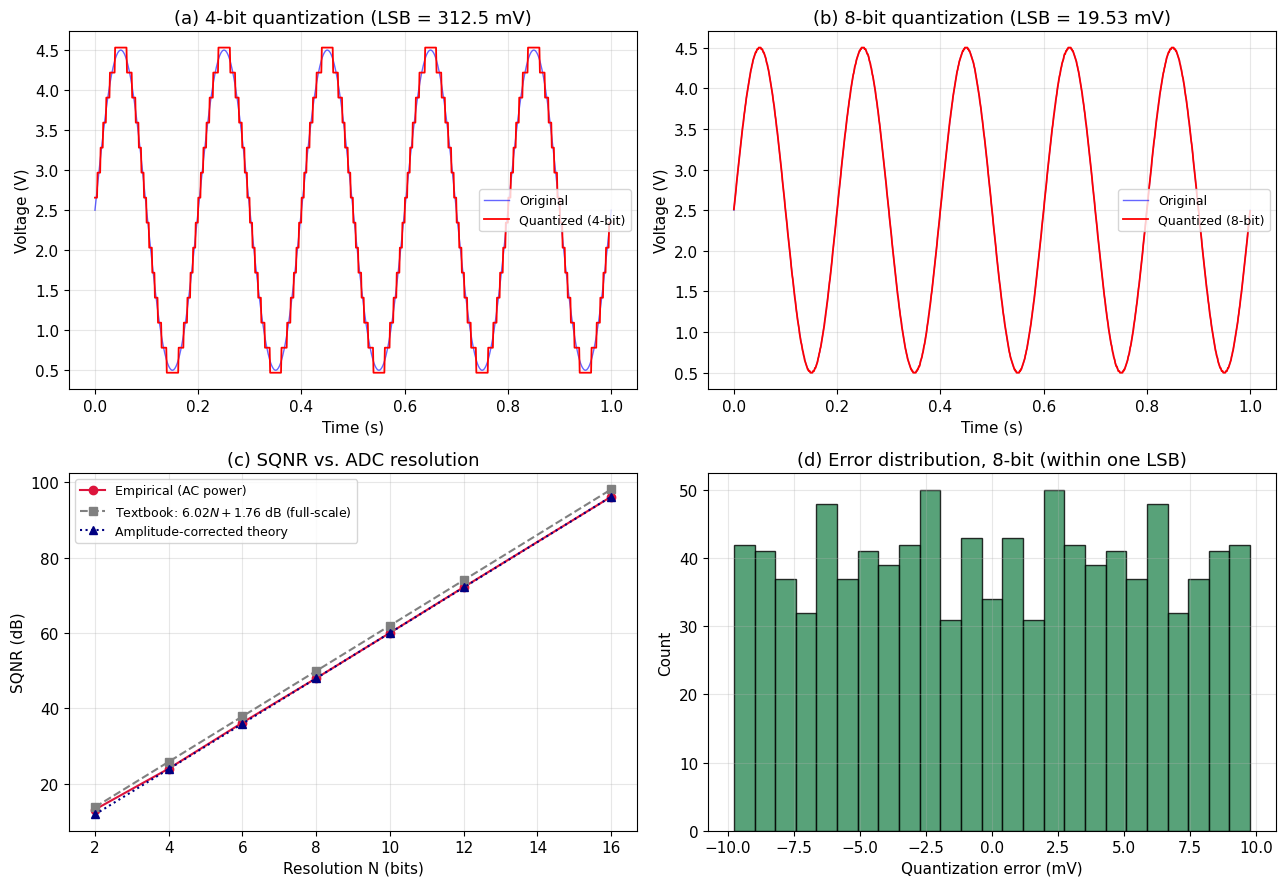

In [6]:
# -- Figure 13.2: quantization at two resolutions, SQNR sweep, error hist ─
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

q4, step4 = quantize(input_signal, 4, v_ref)
ax = axes[0, 0]
ax.plot(t, input_signal, 'b-', lw=1, alpha=0.6, label='Original')
ax.plot(t, q4, 'r-', lw=1.3, label='Quantized (4-bit)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Voltage (V)')
ax.set_title(f'(a) 4-bit quantization (LSB = {step4*1000:.1f} mV)')
ax.legend()

ax = axes[0, 1]
ax.plot(t, input_signal, 'b-', lw=1, alpha=0.6, label='Original')
ax.plot(t, q8, 'r-', lw=1.3, label='Quantized (8-bit)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Voltage (V)')
ax.set_title(f'(b) 8-bit quantization (LSB = {step8*1000:.2f} mV)')
ax.legend()

ax = axes[1, 0]
ax.plot(bit_list, sqnr_emp, 'o-', color='crimson', label='Empirical (AC power)')
ax.plot(bit_list, sqnr_th, 's--', color='gray',
        label='Textbook: $6.02N+1.76$ dB (full-scale)')
ax.plot(bit_list, sqnr_th_adj, '^:', color='navy',
        label='Amplitude-corrected theory')
ax.set_xlabel('Resolution N (bits)'); ax.set_ylabel('SQNR (dB)')
ax.set_title('(c) SQNR vs. ADC resolution')
ax.legend()

ax = axes[1, 1]
err8 = q8 - input_signal
ax.hist(err8 * 1000, bins=25, color='seagreen', edgecolor='k', alpha=0.8)
ax.set_xlabel('Quantization error (mV)'); ax.set_ylabel('Count')
ax.set_title('(d) Error distribution, 8-bit (within one LSB)')

plt.tight_layout()
plt.savefig('fig_13_2_quantization.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

Comparing the naive textbook prediction to the raw empirical SQNR
initially shows a roughly constant offset of a few decibels at every
resolution. The explanation is that the $6.02N+1.76$ dB formula assumes
the input is a sine wave that fills the *entire* converter range,
$\pm V_{ref}/2$. Here the test signal has amplitude $A=2.0$ V against a
half-range of $V_{ref}/2=2.5$ V, i.e., it uses only 80% of the available
swing. Correcting the theoretical formula by
$20\log_{10}\!\big((V_{ref}/2)/A\big) = 1.938$ dB brings it into
agreement with the measured values to within about 0.3 dB for every
resolution from 4 to 16 bits. At 2 bits the match is noticeably worse
($\approx 1.3$ dB residual), because with only four quantization levels
the error signal is too coarse to behave like the "white, uniformly
distributed" noise the formula assumes -- a reminder that the
$6.02N+1.76$ dB rule is itself a large-word-length approximation.

**Figures 13.2(a)-(b)** show the quantized waveform visibly staircasing
at 4 bits (16 levels), while the 8-bit version (256 levels) is already
difficult to distinguish from the original by eye. **Figure 13.2(d)**
confirms that the 8-bit quantization error is approximately uniformly
distributed within one LSB, which is precisely the assumption underlying
the SQNR formula. The sanity check confirms the quantizer never produces
a value at or above $V_{ref}$ and never uses more than the $2^N$ codes
available to it -- a small but important implementation detail, since a
quantizer that silently allows $2^N+1$ output levels no longer
represents a real $N$-bit converter.

> **Key takeaway.** Every additional bit of ADC resolution buys
> approximately 6 dB of SQNR -- but only if the input signal is scaled
> to use the converter's full range. A sensor front-end that wastes half
> the input range throws away roughly one effective bit of resolution
> before a single sample is even quantized; correct gain staging ahead
> of the ADC is therefore as important as the ADC's nominal resolution.

### Challenge tasks

1. Rescale the test signal to use the converter's range as fully as
   possible without clipping -- for example
   $x(t) = V_{ref}/2 + 0.49\,V_{ref}\sin(2\pi \cdot 5t)$, which keeps a
   small margin below the rails -- and confirm that the empirical SQNR
   now matches the unadjusted textbook formula directly. (Setting the
   amplitude to exactly $V_{ref}/2$ with zero offset will clip a
   unipolar 0-to-$V_{ref}$ quantizer on every negative half-cycle; think
   through why before running the cell.)
2. Add a small amount of random dither noise (amplitude
   $\approx 1$ LSB) *before* quantizing a very-low-amplitude, near-DC
   input. Does dithering improve or worsen the mean-square error?
   Explain the effect on correlated quantization error and harmonic
   distortion.
3. Implement a simple $\mu$-law (non-uniform) quantizer and compare its
   SQNR against uniform quantization for a signal with a large
   peak-to-average ratio.
4. Repeat the sweep for a triangular input instead of a sine wave. Does
   the $6.02N+1.76$ dB approximation still hold, and if not, by how much
   does it differ?

---
## Exercise 13.3 -- Anti-Aliasing Filtering: Protecting the ADC from Out-of-Band Interference

### Background

In Exercise 13.1, aliasing was demonstrated with a single, isolated
tone. In practice, a sensor front-end is rarely that clean: a slow
signal of genuine interest (e.g., a 2 Hz vibration or a slowly drifting
environmental quantity) is often accompanied by faster interference --
switching-regulator noise, motor commutation, or mechanical resonances
-- well above the Nyquist frequency of a low-power, low-rate ADC.

This exercise models a **causal, single-pass analog Butterworth
filter** -- exactly the kind of physical circuit that would sit between
a sensor and an ADC -- rather than a non-causal, zero-phase digital
filter. This distinction matters: a real anti-aliasing filter must be
causal (it cannot see future samples) and analog (it must act before
the ADC even runs), and any causal filter with finite roll-off
necessarily introduces delay between input and output. The filter here
is designed with a deliberate **guard band**: its passband edge sits at
or just above the highest frequency of genuine interest, and its cutoff
sits below the Nyquist frequency, leaving room for the filter's finite
roll-off before the Nyquist frequency is reached.

A second, important question this exercise answers directly: once a
signal has been sampled *without* adequate filtering, can a digital
filter fix the damage afterward? The honest answer depends entirely on
whether the alias lands on top of the signal of interest or somewhere
else in the spectrum -- and this exercise tests both cases explicitly,
rather than asserting the general claim without demonstrating it.

In [7]:
# -- Exercise 13.3: causal analog anti-aliasing filter ------------------
f_sig = 2.0                       # Hz: desired signal
f_int1, f_int2 = 47.0, 42.0       # Hz: two out-of-band interferers, tested separately
fs = 20.0                          # Hz: ADC sampling rate (Nyquist frequency = 10 Hz)
duration = 6.0
noise_std = 0.03                   # measurement noise, V

fs_cont = 2000.0                   # "continuous-time" reference rate
t_cont = np.arange(0, duration, 1 / fs_cont)
clean_cont = np.sin(2 * np.pi * f_sig * t_cont)
raw1_cont = clean_cont + 0.8 * np.sin(2 * np.pi * f_int1 * t_cont)
raw2_cont = clean_cont + 0.8 * np.sin(2 * np.pi * f_int2 * t_cont)

# Guard band: passband edge just above the 2 Hz signal (~5 Hz, -1 dB point),
# -3 dB cutoff at 6 Hz (a factor of 3 above the signal, about 1.6 octaves),
# order 4, safely below the 10 Hz Nyquist frequency.
cutoff_hz, order = 6.0, 4
b, a = butter(order, 2 * np.pi * cutoff_hz, btype='low', analog=True)

# Causal time-domain simulation: single forward pass through the analog
# transfer function (physically realizable, unlike filtfilt).
_, filtered1_cont, _ = lsim((b, a), U=raw1_cont, T=t_cont)

# Magnitude, phase delay, and group delay of the analog filter
w_check = 2 * np.pi * np.array([f_sig, fs / 2, f_int1])
_, h_check = freqs(b, a, worN=w_check)
mag_db = 20 * np.log10(np.abs(h_check))
phase = np.angle(h_check)
phase_delay_ms = -phase[0] / (2 * np.pi * f_sig) * 1000

domega = 2 * np.pi * 0.01  # small step for a numerical derivative, rad/s
_, h_lo = freqs(b, a, worN=[2 * np.pi * f_sig - domega])
_, h_hi = freqs(b, a, worN=[2 * np.pi * f_sig + domega])
group_delay_ms = -(np.angle(h_hi)[0] - np.angle(h_lo)[0]) / (2 * domega) * 1000

print(f"Filter: causal analog Butterworth, order {order}, cutoff {cutoff_hz} Hz")
print(f"  |H(f_sig={f_sig:.0f} Hz)|   = {mag_db[0]:7.4f} dB")
print(f"  |H(Nyquist={fs/2:.0f} Hz)| = {mag_db[1]:7.2f} dB")
print(f"  |H(f_int={f_int1:.0f} Hz)|  = {mag_db[2]:7.2f} dB")
print(f"  Phase delay at {f_sig:.0f} Hz: {phase_delay_ms:.2f} ms  "
      f"(exact, valid for this single pure tone)")
print(f"  Group delay at {f_sig:.0f} Hz: {group_delay_ms:.2f} ms  "
      f"(-dphi/domega; relevant once the signal has more than one component)")


def fold_frequency(f_true, fs):
    f_mod = f_true % fs
    return fs - f_mod if f_mod > fs / 2 else f_mod


print(f"\nInterferer A: {f_int1:.0f} Hz aliases to "
      f"{fold_frequency(f_int1, fs):.1f} Hz (does NOT overlap the 2 Hz signal)")
print(f"Interferer B: {f_int2:.0f} Hz aliases to "
      f"{fold_frequency(f_int2, fs):.1f} Hz (overlaps the 2 Hz signal exactly)")

Filter: causal analog Butterworth, order 4, cutoff 6.0 Hz
  |H(f_sig=2 Hz)|   = -0.0007 dB
  |H(Nyquist=10 Hz)| =  -17.82 dB
  |H(f_int=47 Hz)|  =  -71.52 dB
  Phase delay at 2 Hz: 70.46 ms  (exact, valid for this single pure tone)
  Group delay at 2 Hz: 72.94 ms  (-dphi/domega; relevant once the signal has more than one component)

Interferer A: 47 Hz aliases to 7.0 Hz (does NOT overlap the 2 Hz signal)
Interferer B: 42 Hz aliases to 2.0 Hz (overlaps the 2 Hz signal exactly)


In [8]:
# -- Sampling, shared noise, and delay-compensated comparison ----------
settle = 1.5  # s; discard the filter's startup transient before evaluating

idx = (np.arange(0, duration, 1 / fs) * fs_cont).astype(int)
idx = idx[idx < len(t_cont)]
t_s = t_cont[idx]
keep = t_s >= settle

# ONE shared noise realization added to every branch below, so that any
# difference in the results is attributable to filtering choices alone.
shared_noise = np.random.normal(0, noise_std, len(idx))
s_unfiltered_1 = raw1_cont[idx] + shared_noise      # 47 Hz interferer, no AA filter
s_filtered_1 = filtered1_cont[idx] + shared_noise   # 47 Hz interferer, WITH AA filter
s_unfiltered_2 = raw2_cont[idx] + shared_noise      # 42 Hz interferer, no AA filter
s_truth = clean_cont[idx]                            # undelayed reference
# delay-compensated reference: valid because the signal of interest is a
# pure tone, so in steady state the causal filter's output is simply a
# phase-shifted copy of the input at that one frequency
s_truth_delayed = np.sin(2 * np.pi * f_sig * t_s + phase[0])

rms_unfilt_1 = np.sqrt(np.mean((s_unfiltered_1[keep] - s_truth[keep]) ** 2))
rms_filt_1_delayed = np.sqrt(np.mean((s_filtered_1[keep] - s_truth_delayed[keep]) ** 2))
print(f"47 Hz interferer, RMS error, no AA filter (vs. true signal):     {rms_unfilt_1:.4f} V")
print(f"47 Hz interferer, RMS error, with AA filter (delay-compensated): {rms_filt_1_delayed:.4f} V")


def band_snr(samples, fs, f_target, bw=0.5):
    # Delay-invariant spectral SNR: unaffected by the filter's phase shift.
    n = len(samples)
    spec = np.abs(np.fft.rfft(samples * np.hanning(n))) ** 2
    freqs_ = np.fft.rfftfreq(n, d=1 / fs)
    sig_mask = np.abs(freqs_ - f_target) <= bw
    sig_power = spec[sig_mask].sum()
    noise_power = spec.sum() - sig_power
    return 10 * np.log10(sig_power / noise_power)


snr_unfiltered_1 = band_snr(s_unfiltered_1[keep], fs, f_sig)
snr_filtered_1 = band_snr(s_filtered_1[keep], fs, f_sig)
print(f"\nSpectral SNR, 47 Hz case, no AA filter:   {snr_unfiltered_1:.2f} dB")
print(f"Spectral SNR, 47 Hz case, with AA filter: {snr_filtered_1:.2f} dB")

# -- Can a DIGITAL filter fix aliasing after the fact, with no AA filter? --
# Applied AFTER sampling, on records that were never analog-filtered.
bd, ad = butter(4, 4.5 / (fs / 2), btype='low')   # digital LPF, cutoff 4.5 Hz
posthoc_1 = filtfilt(bd, ad, s_unfiltered_1[keep])   # 47 Hz case: alias at 7 Hz
posthoc_2 = filtfilt(bd, ad, s_unfiltered_2[keep])   # 42 Hz case: alias at 2 Hz
rms_posthoc_1 = np.sqrt(np.mean((posthoc_1 - s_truth[keep]) ** 2))
rms_unfilt_2 = np.sqrt(np.mean((s_unfiltered_2[keep] - s_truth[keep]) ** 2))
rms_posthoc_2 = np.sqrt(np.mean((posthoc_2 - s_truth[keep]) ** 2))

print(f"\nPost-hoc digital low-pass filter (4.5 Hz cutoff), applied AFTER "
      f"sampling with no analog AA filter in the chain:")
print(f"  47 Hz interferer (alias at 7 Hz, non-overlapping): "
      f"{rms_unfilt_1:.4f} V raw -> {rms_posthoc_1:.4f} V after digital filtering")
print(f"  42 Hz interferer (alias at 2 Hz, exact overlap):   "
      f"{rms_unfilt_2:.4f} V raw -> {rms_posthoc_2:.4f} V after digital filtering")

47 Hz interferer, RMS error, no AA filter (vs. true signal):     0.5636 V
47 Hz interferer, RMS error, with AA filter (delay-compensated): 0.0279 V

Spectral SNR, 47 Hz case, no AA filter:   1.93 dB
Spectral SNR, 47 Hz case, with AA filter: 28.05 dB

Post-hoc digital low-pass filter (4.5 Hz cutoff), applied AFTER sampling with no analog AA filter in the chain:
  47 Hz interferer (alias at 7 Hz, non-overlapping): 0.5636 V raw -> 0.0710 V after digital filtering
  42 Hz interferer (alias at 2 Hz, exact overlap):   0.5663 V raw -> 0.5652 V after digital filtering


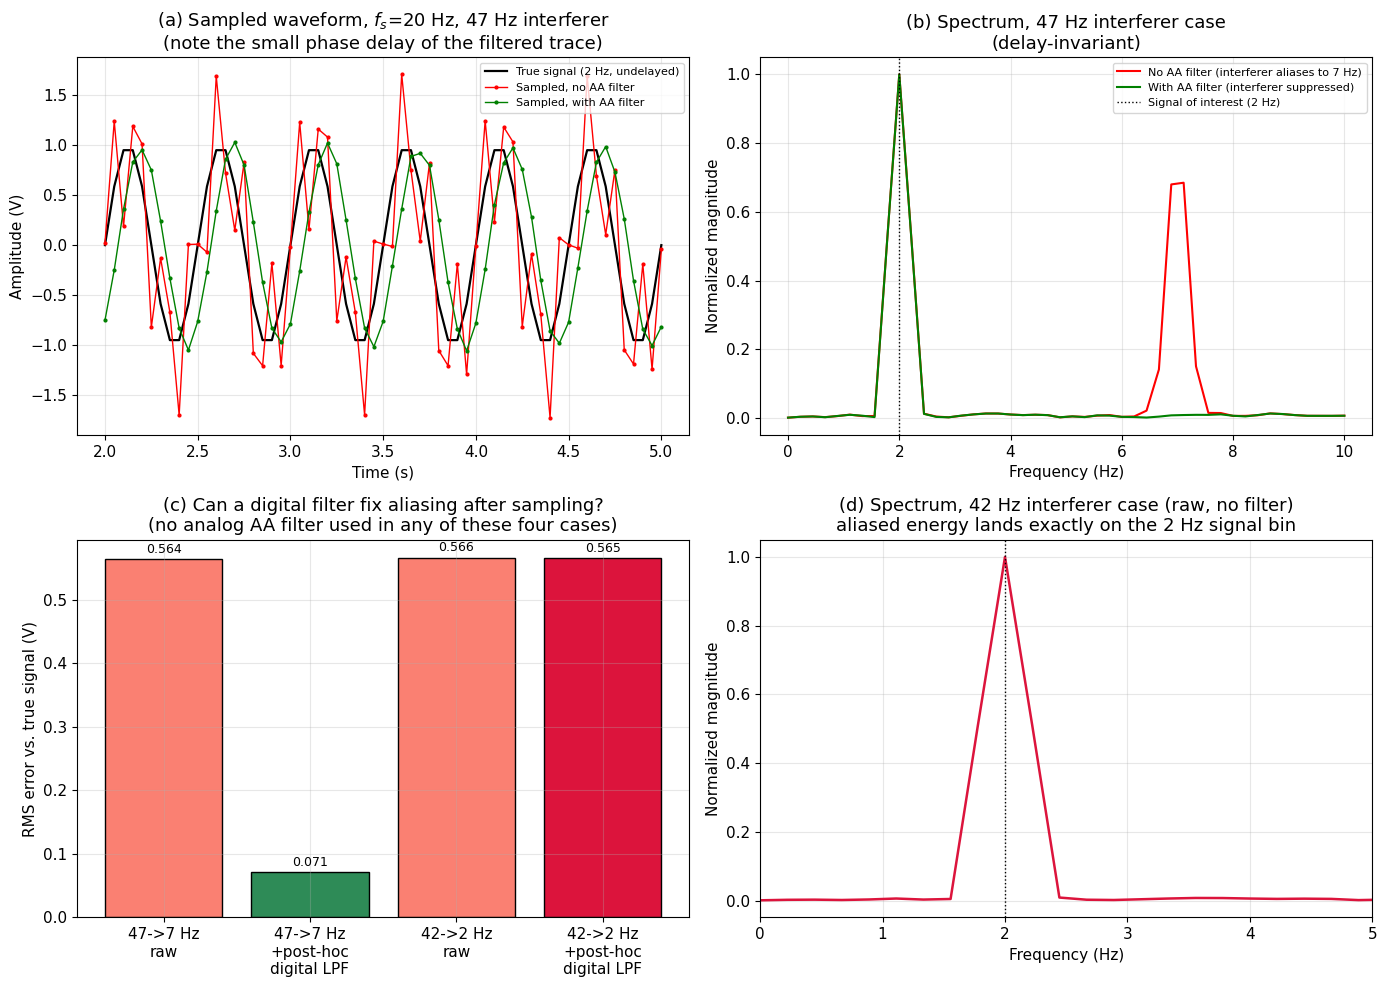

In [9]:
# -- Figure 13.3: causal AA filtering, and the limits of fixing aliasing
# -- after the fact -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
t0, t1 = 2.0, 5.0
m = (t_s >= t0) & (t_s <= t1)
ax.plot(t_s[m], s_truth[m], 'k-', lw=1.6, label='True signal (2 Hz, undelayed)')
ax.plot(t_s[m], s_unfiltered_1[m], 'r.-', lw=1, ms=4, label='Sampled, no AA filter')
ax.plot(t_s[m], s_filtered_1[m], 'g.-', lw=1, ms=4, label='Sampled, with AA filter')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (V)')
ax.set_title('(a) Sampled waveform, $f_s$=20 Hz, 47 Hz interferer\n'
              '(note the small phase delay of the filtered trace)')
ax.legend(fontsize=8)


def spec(x, fs):
    n = len(x)
    S = np.abs(np.fft.rfft(x * np.hanning(n)))
    f = np.fft.rfftfreq(n, d=1 / fs)
    return f, S / S.max()


ax = axes[0, 1]
f1, S1 = spec(s_unfiltered_1[keep], fs)
f2, S2 = spec(s_filtered_1[keep], fs)
ax.plot(f1, S1, 'r-', label='No AA filter (interferer aliases to 7 Hz)')
ax.plot(f2, S2, 'g-', label='With AA filter (interferer suppressed)')
ax.axvline(f_sig, color='k', ls=':', lw=1, label='Signal of interest (2 Hz)')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Normalized magnitude')
ax.set_title('(b) Spectrum, 47 Hz interferer case\n(delay-invariant)')
ax.legend(fontsize=8)

ax = axes[1, 0]
bar_labels = ['47->7 Hz\nraw', '47->7 Hz\n+post-hoc\ndigital LPF',
              '42->2 Hz\nraw', '42->2 Hz\n+post-hoc\ndigital LPF']
bar_vals = [rms_unfilt_1, rms_posthoc_1, rms_unfilt_2, rms_posthoc_2]
bar_colors = ['salmon', 'seagreen', 'salmon', 'crimson']
bars = ax.bar(bar_labels, bar_vals, color=bar_colors, edgecolor='k')
ax.set_ylabel('RMS error vs. true signal (V)')
ax.set_title('(c) Can a digital filter fix aliasing after sampling?\n'
              '(no analog AA filter used in any of these four cases)')
for bar_, v in zip(bars, bar_vals):
    ax.text(bar_.get_x() + bar_.get_width() / 2, v + 0.01, f'{v:.3f}',
            ha='center', fontsize=9)

ax = axes[1, 1]
f3, S3 = spec(s_unfiltered_2[keep], fs)
ax.plot(f3, S3, color='crimson', lw=1.8)
ax.axvline(f_sig, color='k', ls=':', lw=1)
ax.set_xlim(0, 5)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Normalized magnitude')
ax.set_title('(d) Spectrum, 42 Hz interferer case (raw, no filter)\n'
              'aliased energy lands exactly on the 2 Hz signal bin')

plt.tight_layout()
plt.savefig('fig_13_3_antialiasing.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

The filter's own frequency response already tells most of the story:
essentially no attenuation at the 2 Hz signal, about $-18$ dB at the
10 Hz Nyquist frequency, and roughly $-71$ dB at the 47 Hz interferer --
comfortably enough to make the aliased component negligible. The price
of this rejection, for a causal fourth-order filter with its cutoff a
factor of three above the signal (about 1.6 octaves), is a **phase
delay** of about 70 ms at 2 Hz -- an exact, valid correction for this
single pure tone -- and a very similar **group delay** of about 73 ms
(the frequency-dependent quantity that would matter for a broadband
signal with more than one component). **Figure 13.3(a)** shows the
filtered (green) trace visibly shifted relative to the unfiltered
signal, which is expected and correct behaviour for any causal filter,
not a bug.

Two metrics separate the filter's noise-rejection benefit from this
delay. The spectral SNR (which depends only on signal magnitude at each
frequency, not on phase, and is therefore delay-invariant) improves from
about 2 dB with no filter to about 28 dB with the filter. The
delay-compensated RMS error drops from roughly 0.56 V to a value close
to the 0.03 V measurement-noise floor. **Figure 13.3(b)** shows why:
with no filter, the interferer reappears squarely inside the 0-10 Hz
passband at its aliased location (7 Hz); with the filter, it is
suppressed before sampling and the spectrum is clean.

**Now the more important question: could a digital filter, applied
after the fact, have fixed this without any analog anti-aliasing filter
at all?** The answer, shown in Figure 13.3(c)-(d), is: *it depends
entirely on where the alias lands.* For the 47 Hz interferer (aliasing
to 7 Hz, well clear of the 2 Hz signal), a plain digital low-pass filter
applied after sampling recovers most of the lost accuracy -- RMS error
falls from 0.564 V to 0.071 V, because 7 Hz and 2 Hz are spectrally
distinguishable and a filter that knows the signal of interest is
narrowband can separate them. But for the 42 Hz interferer, which
aliases via Eq. (13.1)-style folding to exactly 2 Hz, the same digital
filter changes nothing at all (0.566 V before, 0.565 V after) --
because, as Figure 13.3(d) shows directly, the aliased energy from the
interferer lands on exactly the same spectral bin as the genuine signal.
There is only one peak at 2 Hz in that record, not two, and no filter
of any kind can separate a single peak into "the part that is real" and
"the part that is not."

> **Key takeaway.** Anti-aliasing filtering must happen in the analog
> domain, strictly *before* the ADC, using a causal filter -- the
> zero-phase, non-causal filtering functions common in offline data
> analysis (such as `filtfilt`) cannot be used to model or implement a
> real anti-aliasing stage. Whether a digital filter can partially repair
> unfiltered data *after* sampling depends entirely on whether the alias
> happens to fall outside the signal's own band (Figure 13.3c's first
> pair of bars) or exactly on top of it (Figure 13.3c's second pair): in
> the first case a narrowband assumption can recover much of what was
> lost; in the second, once an out-of-band interferer has aliased onto a
> frequency the signal itself occupies, it is mathematically
> indistinguishable from a genuine in-band component, and no downstream
> processing can separate the two. A deliberate guard band -- passband
> edge at or just above the signal's highest frequency, cutoff safely
> below the Nyquist frequency -- is what prevents this from happening in
> the first place, at the cost of some delay in the passband.

### Challenge tasks

1. Reduce the filter order from 4 to 2 and to 1, keeping the same 6 Hz
   cutoff. How much residual attenuation remains at 47 Hz, and how does
   the spectral SNR change?
2. The 42 Hz demonstration above used a single-tone signal, so the exact
   overlap was easy to see in the spectrum. Repeat it with a
   two-component signal of interest (e.g., 2 Hz and 3 Hz) and an
   interferer that aliases onto one of those two components. Does the
   other, non-overlapped component survive digital post-processing?
3. Measure the filter's group delay at several frequencies between
   0.5 Hz and 6 Hz (using `scipy.signal.freqs` and a numerical phase
   derivative, as in the code above) and plot it. Is the delay constant
   across the passband, and what does that imply for a signal that is
   not a single pure tone?
4. Replace the Butterworth filter with a Chebyshev Type I filter of the
   same order and cutoff, and compare the transition-band steepness
   against the passband ripple and group delay it introduces.

---
## Exercise 13.4 -- Clock Jitter and the Effective Number of Bits (ENOB)

### Background

An ADC's *nominal* resolution (its number of output bits) is only ever
approached if the sampling clock is perfectly regular. Aperture jitter
-- random timing error in the sampling instants -- adds noise that
depends on both the jitter magnitude and the input frequency. For a
sinusoidal input of frequency $f_{in}$ and RMS sampling jitter $t_j$,
the jitter-limited SNR is

$$\mathrm{SNR}_{jitter} = -20\log_{10}\!\left(2\pi f_{in}\,t_j\right)~\text{dB},$$

the same relationship used throughout the ADC industry to specify clock
requirements. Combined in the power domain with the quantization noise
from Exercise 13.2,

$$\mathrm{SNR}_{total} = -10\log_{10}\!\left(10^{-\mathrm{SQNR}_q/10} + 10^{-\mathrm{SNR}_{jitter}/10}\right)~\text{dB},$$

this determines the ADC's *effective* number of bits,
$\mathrm{ENOB} = (\mathrm{SNR}_{total} - 1.76)/6.02$. Jitter and
quantization are only two of several factors that limit a real
converter's ENOB (thermal noise, reference noise, and nonlinearity also
contribute), but they are the two examined quantitatively in this
chapter.

Two scopes need to be kept separate in what follows. The **analytic
relationship** above depends only on $f_{in}$ and $t_j$ -- it says
nothing about any particular ADC's sample rate, and applies whether the
converter samples at 1 MSps or 1 GSps. The **Monte Carlo simulation**
that validates it, however, does model one specific 20 MSps converter,
and its input-frequency sweep is kept below that converter's own
Nyquist frequency (10 MHz), as it must be for the simulated samples to
mean anything.

In [10]:
# -- Exercise 13.4: aperture jitter and ENOB -- analytic model ---------
N_bits = 12
SQNR_quant = 6.02 * N_bits + 1.76        # dB, full-scale sine assumption


def snr_jitter_db(f_in, t_jitter):
    return -20 * np.log10(2 * np.pi * f_in * t_jitter)


def snr_total_db(f_in, t_jitter, sqnr_q=SQNR_quant):
    sj = snr_jitter_db(f_in, t_jitter)
    total_noise = 10 ** (-sqnr_q / 10) + 10 ** (-sj / 10)
    return -10 * np.log10(total_noise)


def enob(snr_db):
    return (snr_db - 1.76) / 6.02


def crossover_freq(t_jitter, sqnr_q=SQNR_quant):
    # Input frequency at which SNR_jitter = SQNR_quant.
    return 10 ** (-sqnr_q / 20) / (2 * np.pi * t_jitter)


print(f"{N_bits}-bit ADC, quantization-limited SQNR = {SQNR_quant:.2f} dB, "
      f"ENOB (jitter negligible) = {enob(SQNR_quant):.2f} bits\n")

# At the crossover frequency, jitter noise power equals quantization
# noise power, so the combined SNR is 3.01 dB (10*log10(2)) below either
# one alone -- and ENOB there is correspondingly a little lower than the
# quantization-only limit, not equal to it.
crossover_snr = SQNR_quant - 10 * np.log10(2)
print(f"At the crossover frequency itself: combined SNR = {crossover_snr:.2f} dB "
      f"(3.01 dB below {SQNR_quant:.2f} dB), ENOB = {enob(crossover_snr):.2f} bits\n")

print(f"{'RMS jitter':>12} {'crossover frequency':>21}")
print("-" * 36)
for label, tj in [('100 ps', 1e-10), ('1 ns', 1e-9), ('10 ns', 1e-8)]:
    fc = crossover_freq(tj)
    print(f"{label:>12} {fc:18.1f} Hz")

12-bit ADC, quantization-limited SQNR = 74.00 dB, ENOB (jitter negligible) = 12.00 bits

At the crossover frequency itself: combined SNR = 70.99 dB (3.01 dB below 74.00 dB), ENOB = 11.50 bits

  RMS jitter   crossover frequency
------------------------------------
      100 ps           317555.9 Hz
        1 ns            31755.6 Hz
       10 ns             3175.6 Hz


In [11]:
# -- Exercise 13.4: Monte Carlo validation (repeated trials) -----------
def quantize_norm(x, bits):
    # Mid-rise uniform quantizer, bipolar full scale [-1, 1), 2**bits codes.
    levels = 2 ** bits
    step = 2.0 / levels
    code = np.floor(np.clip(x, -1, 1 - 1e-9) / step + levels / 2)
    code = np.clip(code, 0, levels - 1)
    return (code + 0.5) * step - 1.0


fs_adc = 20e6          # fixed ADC sample rate, 20 MSps -> Nyquist = 10 MHz
n_samples = 8192        # coherent record length (power of two)
n_trials = 25            # independent jitter realizations per frequency


def empirical_snr_trial(k_bin, t_jitter, bits, rng):
    # k_bin must be odd (coprime with n_samples=2**13) for coherent
    # sampling, avoiding degenerate periodic sample patterns.
    f_in = k_bin * fs_adc / n_samples
    t_nom = np.arange(n_samples) / fs_adc
    jitter = rng.normal(0, t_jitter, n_samples)
    x = np.sin(2 * np.pi * f_in * (t_nom + jitter))
    xq = quantize_norm(x, bits)
    win = np.hanning(n_samples)
    mag2 = np.abs(np.fft.rfft(xq * win)) ** 2
    lo, hi = max(k_bin - 3, 1), k_bin + 4
    sig_power = mag2[lo:hi].sum()
    noise_power = mag2[1:].sum() - sig_power
    return f_in, 10 * np.log10(sig_power / noise_power)


t_jitter_mc = 1e-9   # 1 ns, representative of a modest microcontroller clock
rng = np.random.default_rng(42)

# Restrict the sweep to f_in <= 0.4 * fs_adc (well inside the Nyquist
# limit of THIS simulated converter) and to at least a handful of signal
# cycles per record, avoiding both Nyquist-edge FFT-bin truncation and
# degenerate low-cycle-count quantization artefacts.
max_k = int(0.4 * n_samples)
ks = np.unique((np.logspace(np.log10(5), np.log10(max_k), 16)).astype(int) | 1)

mc_f, mc_mean, mc_std = [], [], []
print(f"{'f_in (Hz)':>12} {'analytic (dB)':>14} {'MC mean (dB)':>13} "
      f"{'MC std (dB)':>12} {'diff (dB)':>10}")
print("-" * 66)
for k in ks:
    trial_snrs = np.array([empirical_snr_trial(int(k), t_jitter_mc, N_bits, rng)[1]
                            for _ in range(n_trials)])
    f_in = k * fs_adc / n_samples
    a = snr_total_db(f_in, t_jitter_mc)
    mc_f.append(f_in); mc_mean.append(trial_snrs.mean()); mc_std.append(trial_snrs.std())
    print(f"{f_in:12.1f} {a:14.2f} {trial_snrs.mean():13.2f} "
          f"{trial_snrs.std():12.2f} {trial_snrs.mean() - a:10.2f}")

   f_in (Hz)  analytic (dB)  MC mean (dB)  MC std (dB)  diff (dB)
------------------------------------------------------------------
     12207.0          73.40         73.22         0.04      -0.18
     17089.8          72.90         72.78         0.04      -0.12
     26855.5          71.66         71.58         0.08      -0.07
     46386.7          69.04         69.01         0.12      -0.03
     70800.8          66.24         66.23         0.12      -0.01
    104980.5          63.23         63.23         0.09      -0.00
    163574.2          59.60         59.58         0.13      -0.02
    251464.8          55.96         55.99         0.11       0.03
    388183.6          52.23         52.24         0.11       0.01
    598144.5          48.49         48.55         0.12       0.06
    920410.2          44.75         44.73         0.11      -0.02


   1418457.0          41.00         41.01         0.13       0.01


   2185058.6          37.25         37.29         0.12       0.05
   3366699.2          33.49         33.46         0.13      -0.03
   5192871.1          29.73         29.74         0.10       0.01
   7995605.5          25.98         25.98         0.11       0.00


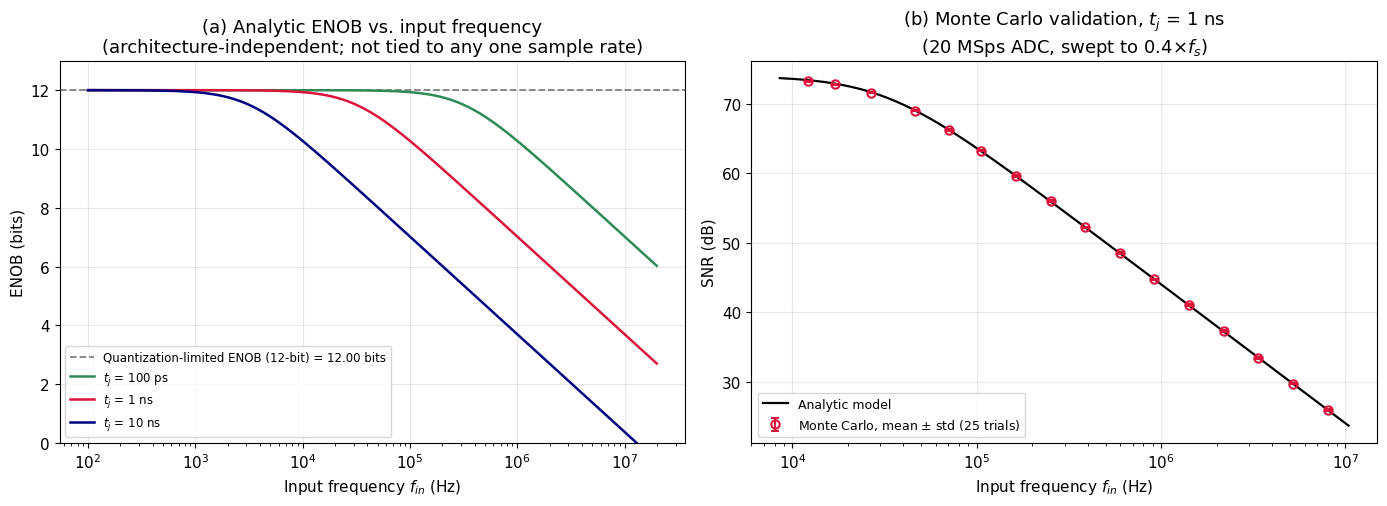

In [12]:
# -- Figure 13.4: ENOB vs frequency, and Monte Carlo validation --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# Panel (a): the analytic ENOB-vs-frequency relationship is architecture-
# and sample-rate-independent, so it is shown over a wide frequency span.
f_range = np.logspace(2, 7.3, 300)
jitters = [1e-10, 1e-9, 1e-8]
labels = ['100 ps', '1 ns', '10 ns']
colors = ['seagreen', 'crimson', 'navy']

ax = axes[0]
ax.axhline(enob(SQNR_quant), color='gray', ls='--', lw=1.3,
           label=f'Quantization-limited ENOB ({N_bits}-bit) '
                 f'= {enob(SQNR_quant):.2f} bits')
for tj, lab, c in zip(jitters, labels, colors):
    e = [enob(snr_total_db(f, tj)) for f in f_range]
    ax.plot(f_range, e, color=c, lw=1.8, label=f'$t_j$ = {lab}')
ax.set_xscale('log')
ax.set_xlabel('Input frequency $f_{in}$ (Hz)')
ax.set_ylabel('ENOB (bits)')
ax.set_title('(a) Analytic ENOB vs. input frequency\n'
              '(architecture-independent; not tied to any one sample rate)')
ax.legend(fontsize=8.5, loc='lower left'); ax.set_ylim(0, 13)

# Panel (b): Monte Carlo validation is necessarily tied to the specific
# 20 MSps converter simulated above, and stays within its Nyquist limit.
ax = axes[1]
f_line = np.logspace(np.log10(mc_f[0] * 0.7), np.log10(mc_f[-1] * 1.3), 200)
snr_line = [snr_total_db(f, t_jitter_mc) for f in f_line]
ax.plot(f_line, snr_line, 'k-', lw=1.6, label='Analytic model')
ax.errorbar(mc_f, mc_mean, yerr=mc_std, fmt='o', color='crimson', ms=6,
            mfc='none', mew=1.5, capsize=3,
            label=f'Monte Carlo, mean $\\pm$ std ({n_trials} trials)')
ax.set_xscale('log')
ax.set_xlabel('Input frequency $f_{in}$ (Hz)')
ax.set_ylabel('SNR (dB)')
ax.set_title(f'(b) Monte Carlo validation, $t_j$ = {t_jitter_mc*1e9:.0f} ns\n'
             f'(20 MSps ADC, swept to 0.4$\\times f_s$)')
ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('fig_13_4_jitter.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

Twenty-five independent jitter realizations were simulated at each test
frequency, and the Monte Carlo mean matches the analytic prediction to
within about 0.2 dB almost everywhere, with the per-frequency standard
deviation typically under 0.15 dB (**Figure 13.4b**). This is a
meaningfully stronger validation than a single realization per point
would give: repeating the trial validates the *expected* SNR at each
frequency and, through the reported standard deviation, quantifies how
much trial-to-trial variability a real, repeatedly clocked converter
would show -- rather than resting on a single simulated run that might
happen to land close to the formula by chance. The sweep was
deliberately kept below 0.4 times the simulated converter's 20 MSps
sample rate; test points closer to that converter's own Nyquist
frequency were found to systematically under-report signal power,
because the analysis window around the signal peak begins to run into
the edge of the one-sided FFT array -- an artefact of the specific
simulation's finite record length near its own Nyquist bin, not a
property of aliasing or of the jitter model itself.

It is also worth being explicit about what the jitter model assumes:
each sample's timing error is drawn independently from the same Gaussian
distribution -- a common and mathematically convenient **white-jitter**
approximation. Real clock sources can exhibit correlated phase noise
(jitter that is similar from one sample to the next, with its own
frequency-domain structure) rather than pure sample-to-sample randomness,
which Eq. (13.4) does not capture; characterising a specific clock
source's actual phase-noise spectrum is a separate measurement task
beyond this exercise's scope.

**Figure 13.4(a)** shows the practical consequence for a 12-bit
converter, and is drawn independently of any particular sample rate,
since the underlying relationship depends only on input frequency and
jitter. At low input frequencies, ENOB sits at the quantization limit of
exactly 12.00 bits (by construction, since $\mathrm{SQNR}_q=74.0$ dB was
chosen to be exactly $6.02\times 12+1.76$), and jitter is irrelevant.
Above the crossover frequency for each jitter level, ENOB falls
sharply. It is worth being precise about what happens exactly at the
crossover frequency: jitter noise power there equals quantization noise
power, so the two combine to a total SNR about 3.01 dB *below* either
one individually -- meaning ENOB at the crossover point itself is
already down to about 11.50 bits, not the full 12.00-bit quantization
limit. A 1 ns clock still delivers only about 7 effective bits at 1 MHz,
and a 10 ns clock collapses to under 5 bits at the same frequency.

> **Key takeaway.** For slow, quasi-static IoT sensors (temperature,
> humidity, most environmental monitoring), clock jitter of even tens of
> nanoseconds is negligible next to quantization noise, so an ordinary
> microcontroller timer is adequate. For high-frequency acquisition --
> vibration analysis, ultrasonic sensing, audio, or radar -- the
> sampling clock's jitter can become a limiting factor alongside the
> ADC's nominal bit count. Jitter and quantization are not the only
> contributors to a real converter's ENOB, but this exercise isolates
> and quantifies their combined effect precisely.

### Challenge tasks

1. Derive the crossover-frequency formula
   $f_c = 10^{-\mathrm{SQNR}_q/20}/(2\pi t_j)$ from
   $\mathrm{SNR}_{jitter}(f_c)=\mathrm{SQNR}_q$, and verify it against
   the printed table. Then derive the ENOB value exactly at $f_c$ and
   confirm the 3.01 dB / 0.5-bit relationship noted above.
2. Repeat the Monte Carlo validation for a 16-bit ADC. At what jitter
   level does the crossover frequency drop into the audio band
   (20 Hz-20 kHz)?
3. Random per-sample jitter can, in principle, be treated like white
   noise: does averaging $M$ oversampled readings recover any of the
   ENOB lost to jitter, the way it does for pure quantization noise?
   Simulate and check whether the improvement follows a $\sqrt{M}$ law,
   and if so, over what range of $M$ it holds.
4. The relationship between oversampling and jitter tolerance is more
   subtle for Sigma-Delta converters than a single rule of thumb can
   capture: it depends on whether the modulator is continuous-time or
   discrete-time, on the input bandwidth, and on where in the clock path
   the jitter is introduced. Read the relevant chapter of
   Pavan, Schreier, and Temes's \emph{Understanding Delta-Sigma Data
   Converters} and summarise, in your own words, under what conditions
   oversampling does and does not relax the clock-jitter requirement
   compared with a Nyquist-rate converter of the same resolution.

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|--------------------|
| 13.1 | Aliasing folding formula + coherent/non-coherent FFT verification | Predicts exactly which frequency an undersampled signal will be mistaken for, and shows the limits of bin-resolution spectral estimates |
| 13.2 | Correctly bounded mid-rise quantizer, SQNR measurement | Quantifies the resolution/range trade-off and the cost of wasted input range |
| 13.3 | Causal analog Butterworth filter with guard band | Demonstrates why filtering must precede sampling, using a physically realizable filter and delay-aware evaluation |
| 13.4 | Aperture-jitter model + repeated Monte Carlo trials | Identifies when clock quality, not ADC bit count, limits real-world resolution |

All four exercises use fixed random seeds so that every reader obtains
the numerical results and figures shown in the printed chapter. Together
they trace the complete signal chain examined in Section 13.2 of the
text: signal -> anti-aliasing filter -> sampling clock -> quantizer ->
digital output -- and show, quantitatively, how an error introduced at
any one stage propagates into the final effective resolution of the
acquisition system.